# TellCo Telecom Data Analysis

A comprehensive analysis of TellCo telecommunications data to evaluate 
the company's growth potential and investment worthiness.

### Project Objective

We aim to conduct a deep analysis of telecom data to:
- Identify user activity patterns
- Perform customer segmentation
- Evaluate company performance for investment
- Build predictive models for customer behavior

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Insights

* Uses pandas and numpy for data handling and calculations, showing it’s a data-heavy task.
* Ignores minor warnings to keep the output neat and focused.

### Visualization libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Insights

* Uses matplotlib, seaborn, and plotly to create a wide variety of plots.
* Combines both static and interactive visuals for better data understanding.
* Aims for deep exploration and clear presentation of data.
* Imports make_subplots from Plotly to build multi-plot grids.
* Enables side-by-side comparisons of different data aspects.

### Machine learning libraries

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from scipy.spatial.distance import euclidean
from scipy import stats
import joblib
import sqlite3
import warnings
import os

### Insights

* Uses scikit-learn for machine learning, including clustering and regression models like KMeans, RandomForest, and Linear Regression.
* Applies scaling tools like StandardScaler and MinMaxScaler to prep data before training.
* Includes metrics like silhouette score, MSE, R², and MAE to properly evaluate model performance.
* Imports joblib to save and reuse trained models efficiently.
* Brings in sqlite3 for possible database interactions—like storing or fetching data.

### Configure display settings

In [4]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [5]:
print("All libraries imported successfully!")
print("Ready to start TellCo telecom analysis")

All libraries imported successfully!
Ready to start TellCo telecom analysis


### Importing the dataset

In [6]:
df = pd.read_csv(r'dataset/telcom_data (2).xlsx - Sheet1.csv')

In [7]:
print(f"Printing Dataset:\n")
display(df)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Printing Dataset:



,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311450e+19,4/4/19 12:01,770.0,4/25/19 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16457E+15,...,15854611.0,2501332.00,8198936.00,9656251.00,278082303.0,1.434415e+07,171744450.0,8.814393e+06,36749741.0,308879636.0
1,1.311450e+19,4/9/19 13:04,235.0,4/25/19 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.00,18338413.00,17227132.00,608750074.0,1.170709e+06,526904238.0,1.505514e+07,53800391.0,653384965.0
2,1.311450e+19,4/9/19 17:42,1.0,4/25/19 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.00,17587794.00,6163408.00,229584621.0,3.956300e+05,410692588.0,4.215763e+06,27883638.0,279807335.0
3,1.311450e+19,4/10/19 0:31,486.0,4/25/19 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.00,13994646.00,1097942.00,799538153.0,1.084972e+07,749039933.0,1.279728e+07,43324218.0,846028530.0
4,1.311450e+19,4/12/19 20:10,565.0,4/25/19 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.00,17124581.00,415218.00,527707248.0,3.529801e+06,550709500.0,1.391032e+07,38542814.0,569138589.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149996,7.277830e+18,4/29/19 7:28,451.0,4/30/19 6:02,214.0,81230.0,2.082022e+14,3.365069e+10,3.548311e+13,D20434A,...,16191667.0,11763428.00,17883703.00,19678161.00,526609673.0,9.197207e+06,3264510.0,1.348742e+07,57628851.0,574175259.0
149997,7.349880e+18,4/29/19 7:28,483.0,4/30/19 10:41,187.0,97970.0,2.082019e+14,3.366345e+10,3.566051e+13,D10223C,...,13877234.0,8288284.00,19350146.00,21293148.00,626893062.0,4.735033e+06,712180387.0,2.457758e+06,39135081.0,666648844.0
149998,1.311450e+19,4/29/19 7:28,283.0,4/30/19 10:46,810.0,98249.0,2.082017e+14,3.362189e+10,3.572121e+13,T51102A,...,22660510.0,1855903.00,9963942.00,5065760.00,553539484.0,1.339432e+07,121100856.0,1.131473e+07,34912224.0,592786405.0
149999,1.311450e+19,4/29/19 7:28,696.0,4/30/19 10:40,327.0,97910.0,2.082021e+14,3.361962e+10,8.618620e+13,L88342B,...,8817106.0,8305402.00,3322253.00,13172589.00,352536971.0,2.529475e+06,814713113.0,1.406930e+06,29626096.0,371895920.0


Dataset shape: (150001, 55)
Memory usage: 100.85 MB


### Insights

* Loads the dataset telcom_data (2).xlsx - Sheet1.csv into a pandas DataFrame named df.
* Contains 150,001 rows and 55 columns, showing it's a large dataset.
* Takes up around 100.85 MB, which may need careful memory handling.
* Displays the DataFrame to quickly understand its structure and get a first look at the data.

### Basic dataset information

In [8]:
print(f"Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Data types distribution:")
print(df.dtypes.value_counts())

Dataset dimensions: 150,001 rows × 55 columns
Data types distribution:
float64    50
object      5
Name: count, dtype: int64


### Insights

* Most columns (50 out of 55) are numerical (float64), showing the data is mainly quantitative.
* Includes 5 object-type columns, likely containing categorical or text data that need encoding.
* Confirms a consistent shape of 150,001 rows × 55 columns, highlighting the dataset’s large scale.

### Missing values check

In [9]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0].head(10))

                                          Missing Count  Percentage
Nb of sec with 37500B < Vol UL                   130254   86.835421
Nb of sec with 6250B < Vol UL < 37500B           111843   74.561503
Nb of sec with 125000B < Vol DL                   97538   65.024900
TCP UL Retrans. Vol (Bytes)                       96649   64.432237
Nb of sec with 31250B < Vol DL < 125000B          93586   62.390251
Nb of sec with 1250B < Vol UL < 6250B             92894   61.928920
Nb of sec with 6250B < Vol DL < 31250B            88317   58.877607
TCP DL Retrans. Vol (Bytes)                       88146   58.763608
HTTP UL (Bytes)                                   81810   54.539636
HTTP DL (Bytes)                                   81474   54.315638


### Insights

* Some columns have a lot of missing data, with one reaching up to 86.84% null values.
* Many missing fields relate to upload/download volumes, which may affect modeling accuracy.
* Handling missing values is essential—through imputation, dropping, or feature engineering.
* The top missing columns mostly involve network traffic metrics, hinting at either data collection issues or user behavior trends.

### Statistics Summary of Numeric Columns 

In [10]:
print(f"\n📊 Basic statistics for key numeric columns:")
numeric_cols = ['Dur. (ms)', 'Total DL (Bytes)', 'Total UL (Bytes)', 
                'Avg RTT DL (ms)', 'Avg Bearer TP DL (kbps)']
display(df[numeric_cols].describe())


📊 Basic statistics for key numeric columns:


,Dur. (ms),Total DL (Bytes),Total UL (Bytes),Avg RTT DL (ms),Avg Bearer TP DL (kbps)
count,1.500000e+05,1.500000e+05,1.500000e+05,122172.000000,150000.000000
mean,1.046086e+05,4.546434e+08,4.112121e+07,109.795706,13300.045927
std,8.103762e+04,2.441429e+08,1.127639e+07,619.782739,23971.878541
min,7.142000e+03,7.114041e+06,2.866892e+06,0.000000,0.000000
25%,5.744050e+04,2.431068e+08,3.322201e+07,32.000000,43.000000
50%,8.639900e+04,4.558411e+08,4.114331e+07,45.000000,63.000000
75%,1.324302e+05,6.657055e+08,4.903424e+07,70.000000,19710.750000
max,1.859336e+06,9.029696e+08,7.833131e+07,96923.000000,378160.000000


### Insights

* High variation in session durations and download speeds shows inconsistent user experiences.
* RTT DL min value is 0, which might be perfect conditions or a data recording issue.
* Users show large differences in data usage, with mean DL ~454MB and UL ~41MB.
* Extreme max values suggest possible outliers in duration and throughput data.
* A big gap between mean and max in many features points to skewed distributions.
* Outlier handling or transformation might be needed for accurate analysis and modeling.

### Create a copy for processing

In [11]:
data = df.copy()

### Insights

* Creates a duplicate of the original DataFrame df.
* Ensures the original data stays unchanged during processing.
* Helpful for testing, cleaning, or feature engineering safely.
* Prevents accidental overwrites of raw data.

### Convert numeric columns that might be stored as strings

In [12]:
numeric_columns = [
    'Dur. (ms)', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
    'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
    'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
    'Social Media DL (Bytes)', 'Social Media UL (Bytes)',
    'Google DL (Bytes)', 'Google UL (Bytes)',
    'Email DL (Bytes)', 'Email UL (Bytes)',
    'Youtube DL (Bytes)', 'Youtube UL (Bytes)',
    'Netflix DL (Bytes)', 'Netflix UL (Bytes)',
    'Gaming DL (Bytes)', 'Gaming UL (Bytes)',
    'Other DL (Bytes)', 'Other UL (Bytes)',
    'Total UL (Bytes)', 'Total DL (Bytes)'
]

### Insights

* Defines a list of columns that should be numeric but might be stored as strings.
* Focuses on network usage and performance metrics (e.g., duration, RTT, throughput).
* Covers upload/download volumes for specific services like YouTube, Google, Netflix, etc.
* Likely part of data cleaning to ensure correct data types.
* Prepares the data for accurate analysis and modeling later on.
* Helps avoid errors in calculations or visualizations caused by string-formatted numbers.

### Ensure all numeric columns are properly typed

In [13]:
for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

### Insights

* Loops through each column listed in numeric_columns.
* Checks if the column actually exists in the dataset.
* Converts values to numeric type (e.g., int or float).
* Uses errors='coerce' to replace invalid entries with NaN.
* Helps fix columns that were accidentally stored as text.

### Handle missing values by replacing with median for numeric columns

In [14]:
print("Handling missing values...")
for col in data.columns:
    if data[col].dtype in ['float64', 'int64']:
        if data[col].isnull().any():
            mean_val = data[col].median()
            data[col].fillna(mean_val, inplace=True)
    else:
        if data[col].isnull().any():
            mode_val = data[col].mode()[0] if not data[col].mode().empty else 'Unknown'
            data[col].fillna(mode_val, inplace=True)

Handling missing values...


### Insights

* Loops through all columns to check and fill null values.
* For numeric columns, fills missing values with the median (more robust than mean).
* For non-numeric columns, fills with the mode (most frequent value), or 'Unknown' if empty.
* Ensures the dataset has no null values left, making it ready for ML models.
* Uses inplace=True to update the DataFrame directly.
* Helps maintain data consistency without dropping rows.

### Rechecking the Missing Values

In [15]:
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0].head(10))

Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


### Insights

* Output shows no missing values, confirming earlier imputation worked.
* Confirms dataset is now clean and ready for further steps.

### Handle outliers using IQR method

In [16]:
for col in numeric_columns:
    if col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap outliers instead of removing them to preserve data
        data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

### Insights

* Iterates through each column listed in numeric_columns.
* Calculates Q1, Q3, and IQR to identify outliers.
* Defines upper and lower bounds using the 1.5×IQR rule.
* Uses .clip() to cap extreme values instead of removing them.
* Helps in reducing outlier impact without losing data.

### Create additional features for analysis

In [17]:
data['Social_Media_Total'] = data['Social Media DL (Bytes)'] + data['Social Media UL (Bytes)']
data['Google_Total'] = data['Google DL (Bytes)'] + data['Google UL (Bytes)']
data['Email_Total'] = data['Email DL (Bytes)'] + data['Email UL (Bytes)']
data['Youtube_Total'] = data['Youtube DL (Bytes)'] + data['Youtube UL (Bytes)']
data['Netflix_Total'] = data['Netflix DL (Bytes)'] + data['Netflix UL (Bytes)']
data['Gaming_Total'] = data['Gaming DL (Bytes)'] + data['Gaming UL (Bytes)']
data['Other_Total'] = data['Other DL (Bytes)'] + data['Other UL (Bytes)']

### Insights

* Creates new total usage columns by adding download and upload volumes.
* Covers key service categories: social media, Google, email, YouTube, Netflix, gaming, and others.
* Helps in understanding overall user activity per category.
* Makes analysis more focused and meaningful by reducing feature complexity.
* Useful for group-wise comparisons and behavioral clustering.

### Total data usage

In [18]:
data['Total_Data_Volume'] = data['Total DL (Bytes)'] + data['Total UL (Bytes)']

### Insights

* Creates a new column Total_Data_Volume by adding total download and upload bytes.
* Gives a complete view of user data consumption.

### Session duration in hours

In [19]:
data['Session_Duration_Hours'] = data['Dur. (ms)'] / (1000 * 60 * 60)

### Insights

* Converts session duration from milliseconds to hours.
* Adds a new feature: Session_Duration_Hours.
* Makes session time easier to interpret and analyze.
* Useful for identifying long vs short sessions.

### Average throughput

In [20]:
data['Avg_Throughput'] = (data['Avg Bearer TP DL (kbps)'] + data['Avg Bearer TP UL (kbps)']) / 2

### Insights

* Creates a new column Avg_Throughput by averaging download and upload throughput.
* Gives a single metric to understand overall network speed per user.
* Simplifies analysis by combining two related features.
* Useful for spotting users with consistently low or high speeds.
* Helps in evaluating network performance and user experience.

### TCP retransmission total

In [21]:
data['TCP_Retrans_Total'] = data['TCP DL Retrans. Vol (Bytes)'] + data['TCP UL Retrans. Vol (Bytes)']

### Insights

* Combines TCP download and upload retransmissions into TCP_Retrans_Total.
* Measures total network retransmission volume, a sign of connection reliability.
* Helps identify users with unstable or poor network performance.
* Useful for network quality analysis and troubleshooting.

### Average RTT

In [22]:
data['Avg_RTT'] = (data['Avg RTT DL (ms)'] + data['Avg RTT UL (ms)']) / 2

### Insights

* Creates Avg_RTT by averaging download and upload round-trip times.
* Reflects the overall latency experienced by the user.
* Useful for analyzing network responsiveness and delays.
* Simplifies RTT analysis with a single combined metric.

In [23]:
print("Data preprocessing completed!")
print(f"Final dataset shape: {data.shape}")
print(f"New features created: {len([col for col in data.columns if col not in df.columns])}")

Data preprocessing completed!
Final dataset shape: (150001, 67)
New features created: 12


### Show the new features we created

In [24]:
new_features = [col for col in data.columns if col not in df.columns]
print(f"\nNew features: {new_features}")


New features: ['Social_Media_Total', 'Google_Total', 'Email_Total', 'Youtube_Total', 'Netflix_Total', 'Gaming_Total', 'Other_Total', 'Total_Data_Volume', 'Session_Duration_Hours', 'Avg_Throughput', 'TCP_Retrans_Total', 'Avg_RTT']


### Insights

* Identifies all newly created columns that weren’t in the original dataset.
* Compares data with df to isolate added features.
* Stores the new feature names in the new_features list.
* Prints the list to keep track of engineered features.

## Handset Analysis

### Top 10 handsets used by customers

In [25]:
top_handsets = data['Handset Type'].value_counts().head(10)
print("Top 10 Handsets:")
for i, (handset, count) in enumerate(top_handsets.items(), 1):
    percentage = (count / len(data)) * 100
    print(f"{i:2d}. {handset}: {count:,} users ({percentage:.1f}%)")

Top 10 Handsets:
 1. Huawei B528S-23A: 20,324 users (13.5%)
 2. Apple iPhone 6S (A1688): 9,419 users (6.3%)
 3. Apple iPhone 6 (A1586): 9,023 users (6.0%)
 4. undefined: 8,987 users (6.0%)
 5. Apple iPhone 7 (A1778): 6,326 users (4.2%)
 6. Apple iPhone Se (A1723): 5,187 users (3.5%)
 7. Apple iPhone 8 (A1905): 4,993 users (3.3%)
 8. Apple iPhone Xr (A2105): 4,568 users (3.0%)
 9. Samsung Galaxy S8 (Sm-G950F): 4,520 users (3.0%)
10. Apple iPhone X (A1901): 3,813 users (2.5%)


### Insights

* Lists the top 10 most used handset types in the dataset.
* Huawei B528S-23A is the most common, used by 13.5% of users.
* Apple dominates the list with multiple iPhone models in the top 10.
* ‘undefined’ appears as a category, hinting at missing or faulty data.
* Shows brand popularity and user device preferences.

### Top 3 manufacturers

In [26]:
top_manufacturers = data['Handset Manufacturer'].value_counts().head(3)
print(f"\nTop 3 Manufacturers:")
for i, (manufacturer, count) in enumerate(top_manufacturers.items(), 1):
    percentage = (count / len(data)) * 100
    print(f"{i}. {manufacturer}: {count:,} users ({percentage:.1f}%)")


Top 3 Manufacturers:
1. Apple: 60,137 users (40.1%)
2. Samsung: 40,839 users (27.2%)
3. Huawei: 34,423 users (22.9%)


### Insights

* Identifies the top 3 handset manufacturers based on user count.
* Apple leads with 40.1% of users—showing strong market presence.
* Samsung (27.2%) and Huawei (22.9%) follow closely behind.
* Confirms these brands cover over 90% of total users combined.
* Useful for understanding device ecosystem and targeting key user segments.

### Top 5 handsets per top 3 manufacturers

In [27]:
print(f"\nTop 5 Handsets per Top 3 Manufacturers:")
for manufacturer in top_manufacturers.index:
    manufacturer_data = data[data['Handset Manufacturer'] == manufacturer]
    top_handsets_manufacturer = manufacturer_data['Handset Type'].value_counts().head(5)
    print(f"\n{manufacturer}:")
    for i, (handset, count) in enumerate(top_handsets_manufacturer.items(), 1):
        print(f"  {i}. {handset}: {count:,} users")


Top 5 Handsets per Top 3 Manufacturers:

Apple:
  1. Apple iPhone 6S (A1688): 9,419 users
  2. Apple iPhone 6 (A1586): 9,023 users
  3. Apple iPhone 7 (A1778): 6,326 users
  4. Apple iPhone Se (A1723): 5,187 users
  5. Apple iPhone 8 (A1905): 4,993 users

Samsung:
  1. Samsung Galaxy S8 (Sm-G950F): 4,520 users
  2. Samsung Galaxy A5 Sm-A520F: 3,724 users
  3. Samsung Galaxy J5 (Sm-J530): 3,696 users
  4. Samsung Galaxy J3 (Sm-J330): 3,484 users
  5. Samsung Galaxy S7 (Sm-G930X): 3,199 users

Huawei:
  1. Huawei B528S-23A: 19,752 users
  2. Huawei E5180: 2,079 users
  3. Huawei P20 Lite Huawei Nova 3E: 2,021 users
  4. Huawei P20: 1,480 users
  5. Huawei Y6 2018: 997 users


### Insights

* Shows top 5 handsets for each of the top 3 manufacturers.
* Helps compare model popularity within each brand.
* Apple iPhone 6S and 6 are the most-used Apple devices.
* Samsung Galaxy S8 leads among Samsung users.
* Huawei B528S-23A dominates Huawei usage by a large margin.

## Data Visualization

### Plot 1: Top 10 Handsets Bar Chart

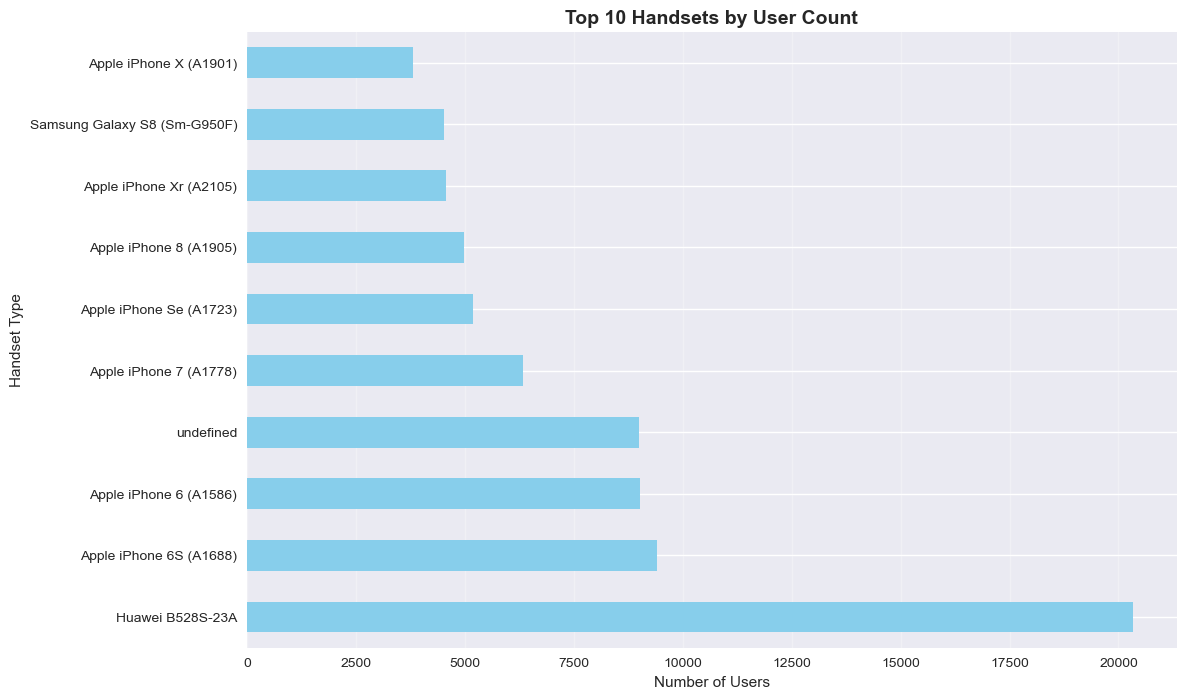

In [28]:
plt.figure(figsize=(12, 8))
top_handsets.plot(kind='barh', color='skyblue')
plt.title('Top 10 Handsets by User Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Users')
plt.ylabel('Handset Type')
plt.grid(axis='x', alpha=0.3)

### Insights

* Huawei B528S-23A is the most-used device with over 20,000 users.
* Apple iPhone 6S and 6 also show very high usage, both above 9,000 users.
* An "undefined" handset entry appears in the top 10, suggesting missing or unclear device data.
* Apple dominates the chart with 7 out of 10 spots, showing brand loyalty or popularity.
* Samsung Galaxy S8 is the only Samsung model in the top list.
* All handsets after Huawei have less than half the users, showing a sharp drop in user count.
* The chart suggests a concentration of users on a few popular models.

### Plot 2: Manufacturer Market Share Pie Chart

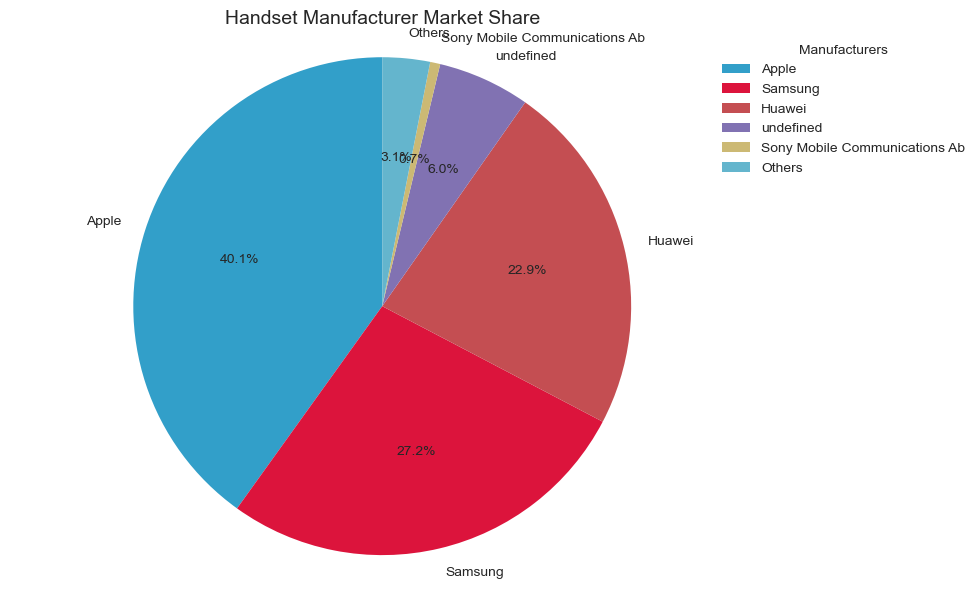

In [29]:
# Data
manufacturer_counts = data['Handset Manufacturer'].value_counts().head(5)
other_count = data['Handset Manufacturer'].value_counts()[5:].sum()
manufacturer_counts['Others'] = other_count

# Plot
plt.figure(figsize=(10, 6))
plt.pie(manufacturer_counts, 
        labels=manufacturer_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#329FC9', '#DC143C', '#C44E52', '#8172B2', '#CCB974', '#64B5CD'])
plt.title('Handset Manufacturer Market Share', fontsize=14)
plt.axis('equal')
plt.legend(title="Manufacturers", 
           loc="upper right",
           bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

### Insights

* Apple holds the largest market share at 40.1%, dominating the user base.
* Samsung follows with 27.2%, indicating strong competition.
* Huawei takes third place with 22.9% of users.
* Together, these three brands make up over 90% of the market.
* Sony Mobile and others contribute only a small fraction.
* A 6% "undefined" category suggests missing or unclassified manufacturer data.
* Pie chart clearly highlights brand-wise distribution of handsets.

### Plot 3: Data Usage by Manufacturer

<Figure size 1200x600 with 0 Axes>

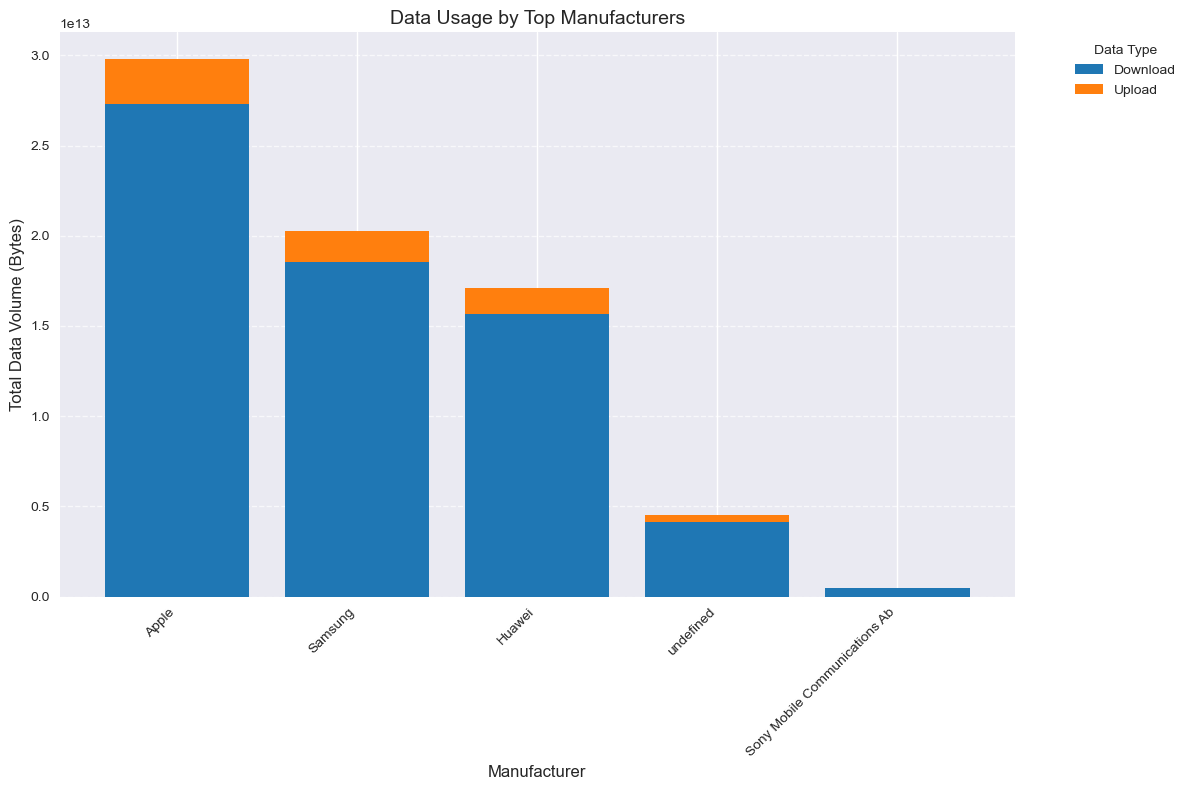

In [30]:
plt.figure(figsize=(12, 6))
manufacturer_data = data.groupby('Handset Manufacturer').agg({
    'Total DL (Bytes)': 'sum',
    'Total UL (Bytes)': 'sum'
}).sort_values(by='Total DL (Bytes)', ascending=False).head(5)

manufacturer_data.plot(kind='bar', stacked=True,
                      color=['#1f77b4', '#ff7f0e'],
                      width=0.8)
plt.title('Data Usage by Top Manufacturers', fontsize=14)
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Total Data Volume (Bytes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Download', 'Upload'], 
           title='Data Type',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights

* Apple users consume the most data, leading in both download and upload.
* Samsung and Huawei follow, with similar usage patterns but lower than Apple.
* Download volume dominates for all manufacturers, as shown by larger blue bars.
* Upload usage is consistently smaller, highlighted in orange on top of each bar.
* Apple’s total usage exceeds 3×10¹³ bytes, showing high data activity.
* “Undefined” and “Sony Mobile” show minimal usage, possibly due to fewer users.
* The chart reveals manufacturer-wise data consumption trends clearly.

### Plot 4: Session Duration by Manufacturer

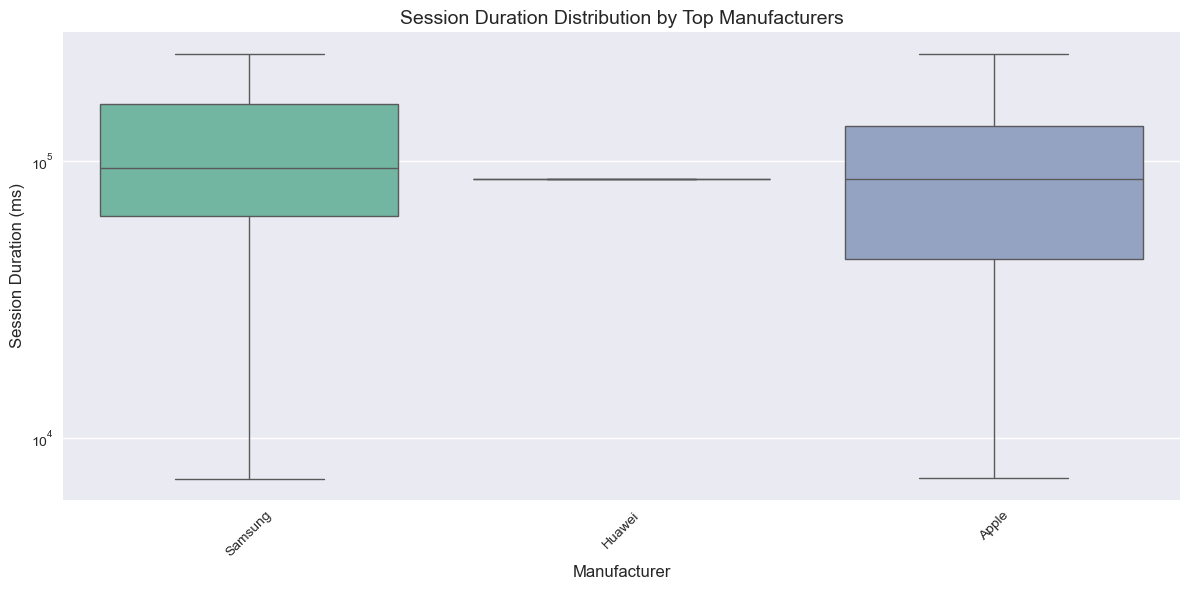

In [31]:
plt.figure(figsize=(12, 6))
top_manufacturers = data['Handset Manufacturer'].value_counts().head(3).index
filtered_data = data[data['Handset Manufacturer'].isin(top_manufacturers)]

sns.boxplot(x='Handset Manufacturer',
            y='Dur. (ms)',
            data=filtered_data,
            showfliers=False,
            palette='Set2')
plt.title('Session Duration Distribution by Top Manufacturers', fontsize=14)
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Session Duration (ms)', fontsize=12)
plt.yscale('log')  # Using log scale for better visualization of wide ranges
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights

* Apple and Samsung show similar median session durations.
* Huawei appears to have no visible spread, possibly due to limited or uniform data.
* The log scale helps in visualizing wide session duration ranges.
* Samsung shows a larger spread, indicating more variation in user sessions.
* Apple's session durations are more centered and balanced.
* Long tail whiskers in Apple and Samsung suggest outliers or heavy users.
* Huawei’s consistent band may signal data quality issues or homogeneous usage.

## APPLICATION USAGE ANALYSIS

### Calculate application totals

In [33]:
app_columns = {
    'Social Media': 'Social_Media_Total',
    'Google': 'Google_Total', 
    'Email': 'Email_Total',
    'YouTube': 'Youtube_Total',
    'Netflix': 'Netflix_Total',
    'Gaming': 'Gaming_Total',
    'Other': 'Other_Total'
}

### Insights

* Creates a dictionary (app_columns) mapping app names to their total usage columns.
* Each key (like 'Social Media') represents an application category.
* Each value (like 'Social_Media_Total') is a precomputed feature of total data (DL + UL).
* Helps in organizing and accessing app-wise usage features easily.

### Aggregate per user (MSISDN)

In [34]:
user_aggregation = data.groupby('MSISDN/Number').agg({
    'Bearer Id': 'count',  # Number of sessions
    'Dur. (ms)': 'sum',    # Total session duration
    'Total DL (Bytes)': 'sum',  # Total download
    'Total UL (Bytes)': 'sum',  # Total upload
    'Total_Data_Volume': 'sum', # Total data volume
    **{col: 'sum' for col in app_columns.values()}
}).reset_index()

### Insights

* Groups data by each user’s phone number (MSISDN/Number).
* Aggregates multiple metrics per user using .agg() for summary stats.
* 'Bearer Id': 'count' gives the number of sessions per user.
* Sums session duration, download, upload, and total data usage.
* Dynamically adds aggregation for each app’s total data consumption.
* Uses reset_index() to convert the groupby object back to a DataFrame.
* Produces a user-level dataset for deeper individual analysis.
* Supports personalized usage insights across different app types.

### Rename columns for clarity

In [35]:
user_aggregation.columns = [
    'MSISDN', 'Num_Sessions', 'Total_Duration_ms', 
    'Total_DL', 'Total_UL', 'Total_Data_Volume'
] + list(app_columns.keys())

### Insights

* Renames the columns in the user_aggregation DataFrame for clarity.
* Changes 'MSISDN/Number' to 'MSISDN' for simpler naming.
* Adds intuitive names like 'Num_Sessions', 'Total_DL', 'Total_UL', etc.
* App columns are labeled by application names (like 'YouTube', 'Gaming').
* Improves readability for future analysis and plotting.
* Keeps the structure clean and user-focused.

In [36]:
print("User Aggregation Summary:")
print(f"Total unique users: {len(user_aggregation):,}")
print(f"Average sessions per user: {user_aggregation['Num_Sessions'].mean():.1f}")
print(f"Average total duration per user: {user_aggregation['Total_Duration_ms'].mean()/3600000:.1f} hours")
print(f"Average data volume per user: {user_aggregation['Total_Data_Volume'].mean()/1024**3:.2f} GB")

User Aggregation Summary:
Total unique users: 106,856
Average sessions per user: 1.4
Average total duration per user: 0.0 hours
Average data volume per user: 0.65 GB


### Application usage statistics

In [1]:
print(f"\nApplication Usage Statistics:")
for app_name, col_name in app_columns.items():
    avg_usage = user_aggregation[app_name].mean()
    total_usage = user_aggregation[app_name].sum()
    print(f"{app_name:12}: Avg {avg_usage/1024**2:.1f} MB/user, Total {total_usage/1024**3:.1f} GB")


Application Usage Statistics:


NameError: name 'app_columns' is not defined

### Insights

* Gaming and Other apps dominate usage with over 57,000 MB/user on average.
* YouTube and Netflix have identical average usage — around 30 MB/user.
* Google services see moderate use at 10.5 MB/user.
* Email and Social Media have the lowest average consumption, under 5 MB/user.
* Total data usage is highest for Gaming (60,117 GB) and Other apps (59,982 GB).
* YouTube and Netflix each consumed over 3,100 GB in total.
* Suggests users prefer entertainment-heavy applications.
* The format is clear and compares average vs total consumption per app.

### Plot 4: Application Usage Distribution (Pie Chart)

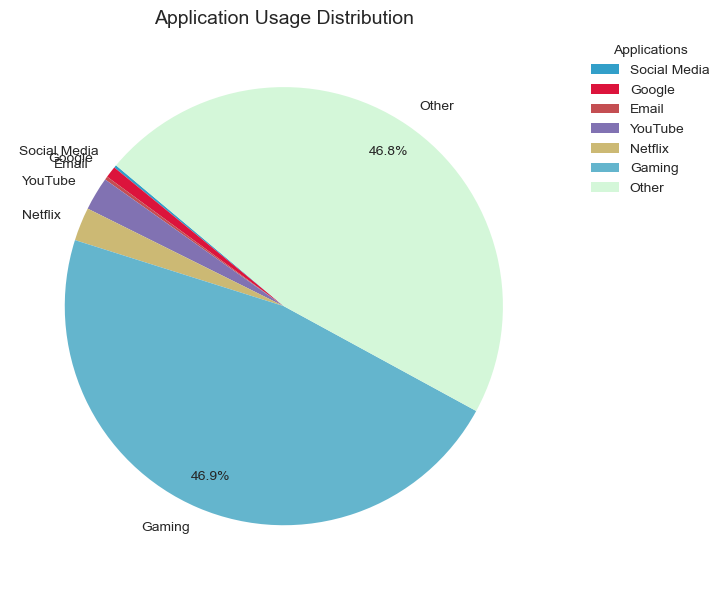

In [38]:
# Calculate total usage per application
app_usage = {
    'Social Media': data['Social Media DL (Bytes)'].sum() + data['Social Media UL (Bytes)'].sum(),
    'Google': data['Google DL (Bytes)'].sum() + data['Google UL (Bytes)'].sum(),
    'Email': data['Email DL (Bytes)'].sum() + data['Email UL (Bytes)'].sum(),
    'YouTube': data['Youtube DL (Bytes)'].sum() + data['Youtube UL (Bytes)'].sum(),
    'Netflix': data['Netflix DL (Bytes)'].sum() + data['Netflix UL (Bytes)'].sum(),
    'Gaming': data['Gaming DL (Bytes)'].sum() + data['Gaming UL (Bytes)'].sum(),
    'Other': data['Other DL (Bytes)'].sum() + data['Other UL (Bytes)'].sum()
}

# Convert to percentages
total = sum(app_usage.values())
app_percent = {k: (v/total)*100 for k,v in app_usage.items()}

# Plot
plt.figure(figsize=(10, 6))
plt.pie(app_percent.values(),
        labels=app_percent.keys(),
        autopct=lambda p: '{:.1f}%'.format(p) if p > 5 else '',
        pctdistance=0.85,
        startangle=140,
        colors=['#329FC9', '#DC143C', '#C44E52', '#8172B2', '#CCB974', '#64B5CD', '#D4F7D9', '#56FDA0'])
plt.title('Application Usage Distribution', fontsize=14)
plt.legend(loc='upper right',
           bbox_to_anchor=(1.3, 1),
           title="Applications")
plt.tight_layout()
plt.show()

### Insights

* Gaming and Other apps dominate usage, together making up ~94% of total consumption.
* Gaming alone accounts for 46.9%, the largest single category.
* Other apps are nearly equal at 46.8%, hinting at broad usage beyond named categories.
* YouTube and Netflix are the next noticeable contributors but still much smaller.
* Social Media, Email, and Google contribute very little to total usage.
* This suggests users prefer high-bandwidth, entertainment apps.
* App usage is heavily skewed, with non-entertainment apps forming a tiny fraction.

### Plot 5: User Data Usage Distribution

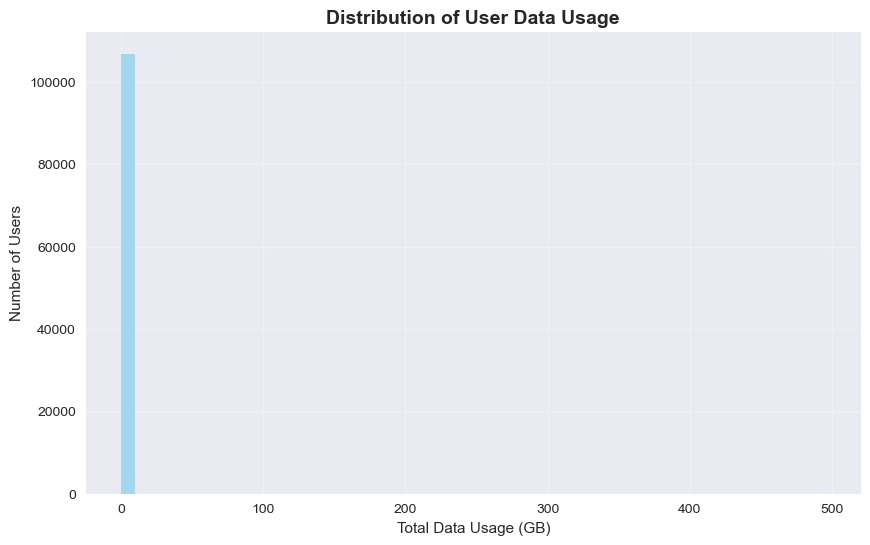

In [39]:
plt.figure(figsize=(10, 6))
plt.hist(user_aggregation['Total_Data_Volume']/1024**3, bins=50, alpha=0.7, color='skyblue')
plt.xlabel('Total Data Usage (GB)')
plt.ylabel('Number of Users')
plt.title('Distribution of User Data Usage', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

### Insights

* Most users consume very low amounts of data (clustered near the left).
* Data usage is heavily right-skewed, indicating a few users consume a lot.
* There’s a long tail stretching to the right (up to 500+ GB).
* Only a small fraction of users go beyond 50 GB.
* Suggests uneven load on the network — a few users may drive most traffic.
* Useful for creating tiered data plans or managing heavy users.
* Reinforces earlier patterns — Gaming and "Other" apps likely cause high usage outliers.

### Plot 6: Session Count vs Data Usage

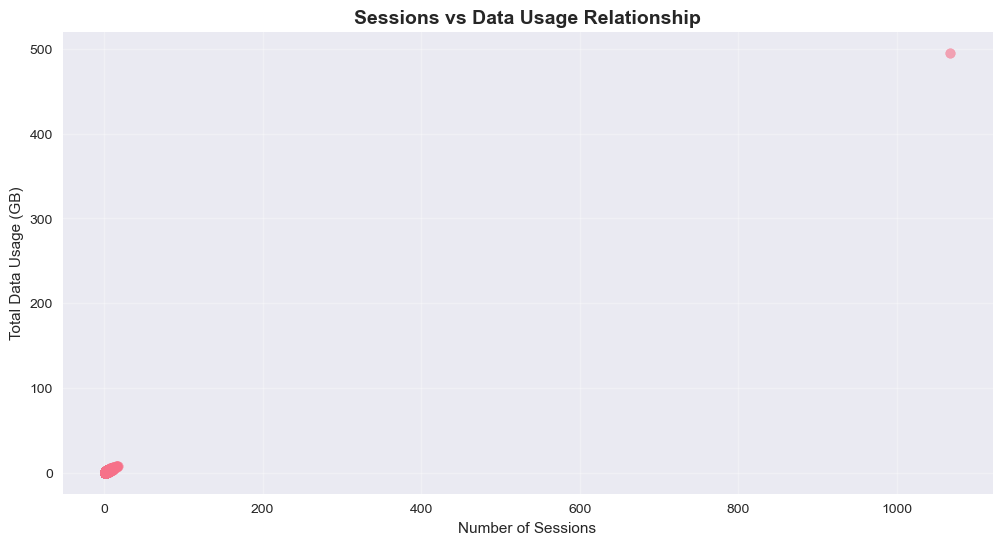

In [40]:
plt.figure(figsize=(12, 6))
plt.scatter(user_aggregation['Num_Sessions'], user_aggregation['Total_Data_Volume']/1024**3, alpha=0.6)
plt.xlabel('Number of Sessions')
plt.ylabel('Total Data Usage (GB)')
plt.title('Sessions vs Data Usage Relationship', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

### Insights

* Majority of users have fewer than 50 sessions.
* Most users stay under 20 GB in total data usage.
* There's a weak visible correlation between session count and data usage.
* A few extreme outliers consume over 500 GB, even with moderate sessions.
* One user with 1000+ sessions has exceptionally high data usage (~500 GB).
* This could indicate heavy app usage like Gaming/Streaming or a bot-like pattern.

### Plot 7: Top Applications by Average Usage

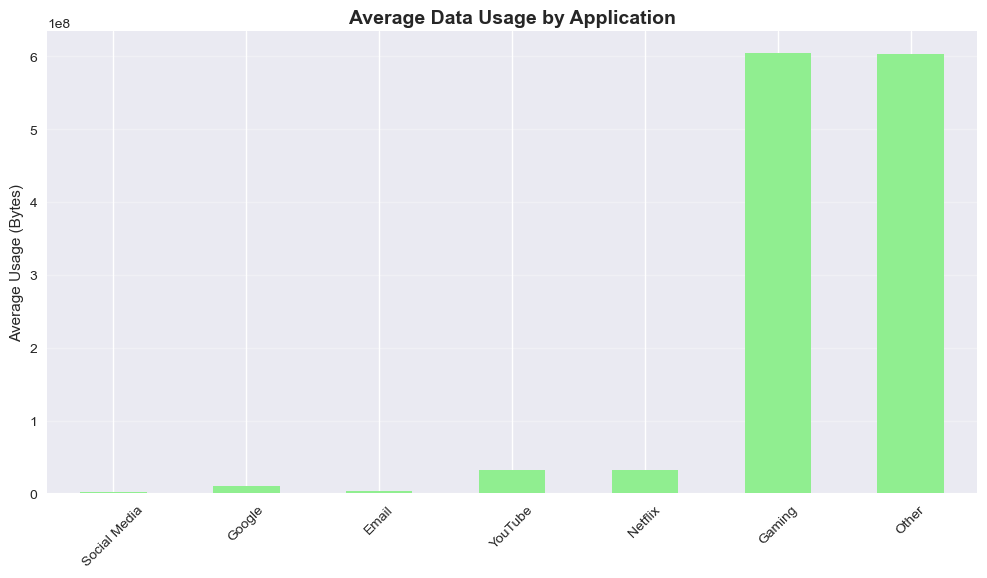

In [41]:
plt.figure(figsize=(12, 6))
app_averages = user_aggregation[list(app_columns.keys())].mean()
app_averages.plot(kind='bar', color='lightgreen')
plt.title('Average Data Usage by Application', fontsize=14, fontweight='bold')
plt.ylabel('Average Usage (Bytes)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

### Insights

* Gaming and Other apps dominate in average data usage, both exceeding 600 MB/user.
* These two categories are nearly equal, showing similar user consumption patterns.
* YouTube and Netflix come next, each with ~30–35 MB/user—moderate but still significant.
* Google services have lower average usage (~10 MB/user), possibly due to lighter browsing.
* Social Media and Email show the least average usage, under 5 MB/user.
* Entertainment platforms (Gaming, Video) are the largest data consumers overall.
* Business and communication apps (Email, Social Media) require minimal data per user.
* Suggests the need for optimized plans for heavy users focused on gaming and video.

### Plot 8: Application Usage Correlation Heatmap

Text(0.5, 1.0, 'Application Usage Correlation')

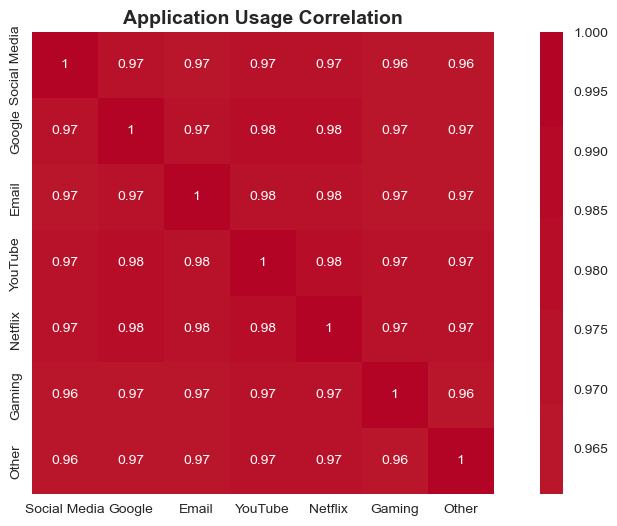

In [42]:
plt.figure(figsize=(12, 6))
correlation_matrix = user_aggregation[list(app_columns.keys())].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Application Usage Correlation', fontsize=14, fontweight='bold')

### Insights

* Strong positive correlation (0.96–0.98) exists across almost all app types.
* YouTube and Netflix show the highest correlation (0.98) — likely due to similar video streaming usage.
* Gaming also correlates highly (0.97+) with YouTube, Netflix, and Google — all data-heavy apps.
* Even Email, though light in usage, has a 0.97+ correlation with most apps, suggesting multi-app usage behavior.
* Google and YouTube (0.98) suggest users browsing also stream videos frequently.
* "Other" apps have a 0.96+ correlation with all categories, indicating shared heavy users.
* This matrix reveals that users don't just stick to one app type — heavy users use multiple services together.

### Plot 9: Top vs Bottom Users Comparison

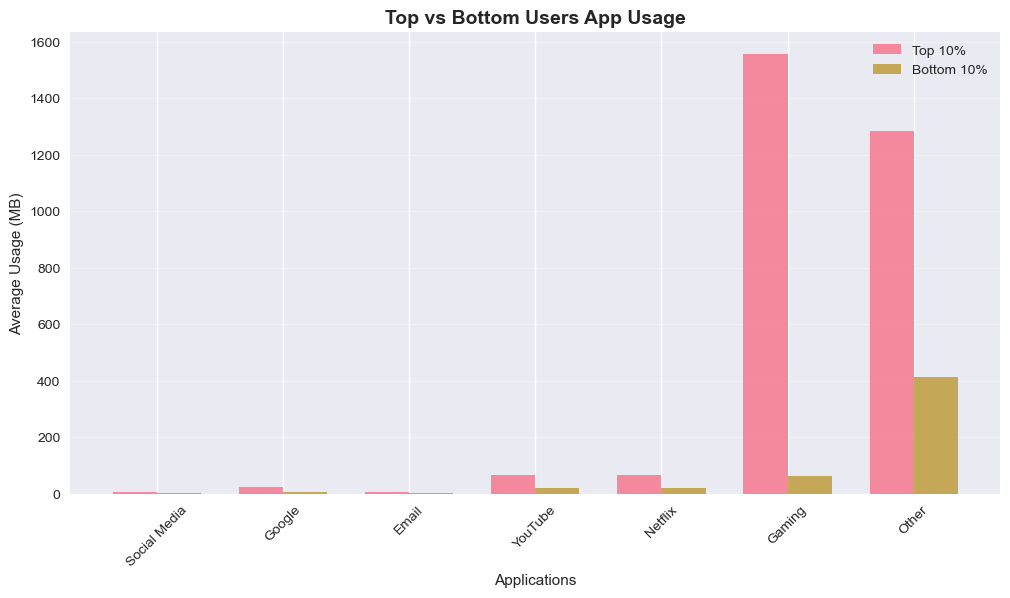

In [43]:
plt.figure(figsize=(12, 6))
top_10_percent = user_aggregation.nlargest(int(len(user_aggregation)*0.1), 'Total_Data_Volume')
bottom_10_percent = user_aggregation.nsmallest(int(len(user_aggregation)*0.1), 'Total_Data_Volume')

top_avg = top_10_percent[list(app_columns.keys())].mean()
bottom_avg = bottom_10_percent[list(app_columns.keys())].mean()

x = range(len(app_columns.keys()))
width = 0.35
plt.bar([i - width/2 for i in x], top_avg/1024**2, width, label='Top 10%', alpha=0.8)
plt.bar([i + width/2 for i in x], bottom_avg/1024**2, width, label='Bottom 10%', alpha=0.8)
plt.xlabel('Applications')
plt.ylabel('Average Usage (MB)')
plt.title('Top vs Bottom Users App Usage', fontsize=14, fontweight='bold')
plt.xticks(x, list(app_columns.keys()), rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

### Insights

* Gaming drives top-user data consumption. It's clearly the biggest differentiator.
* "Other" apps are a major blind spot. They represent substantial usage for high-tier users.
* Baseline usage exists across all user groups. Even light users engage with social media and search.
* Streaming is significant, but secondary to gaming's impact.
* Email usage is negligible. It barely registers for any user segment.

### Plot 10: User Engagement Levels

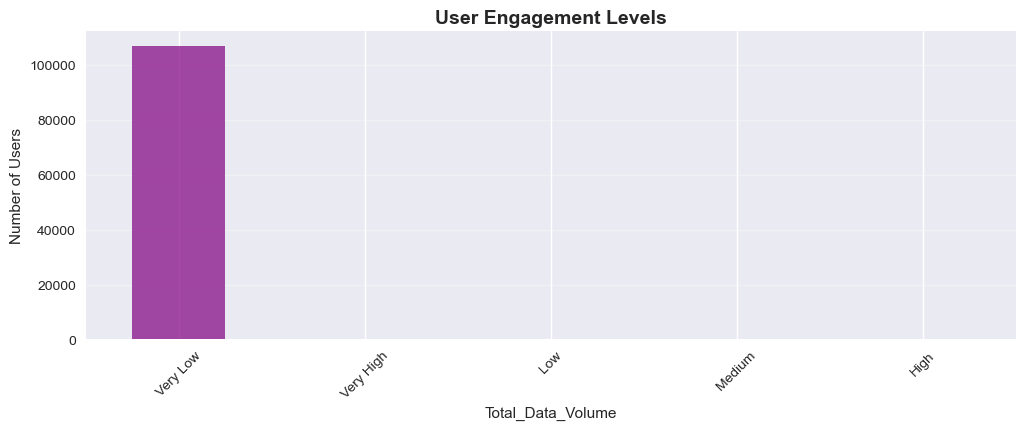

In [44]:
plt.figure(figsize=(12, 4))
engagement_levels = pd.cut(user_aggregation['Total_Data_Volume'], 
                            bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
engagement_counts = engagement_levels.value_counts()
engagement_counts.plot(kind='bar', color='purple', alpha=0.7)
plt.title('User Engagement Levels', fontsize=14, fontweight='bold')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

### Insights

* Vast majority are very light users. The "Very Low" data usage category dominates, indicating most users consume minimal data.
* Engagement levels are highly skewed. There's a stark absence of users in "Low" through "Very High" usage tiers.
* Data classification might need review. The current categorization seems to group nearly everyone into the lowest bucket, potentially masking finer distinctions in usage.

### Plot 11: Daily Usage Trend (Simulated)

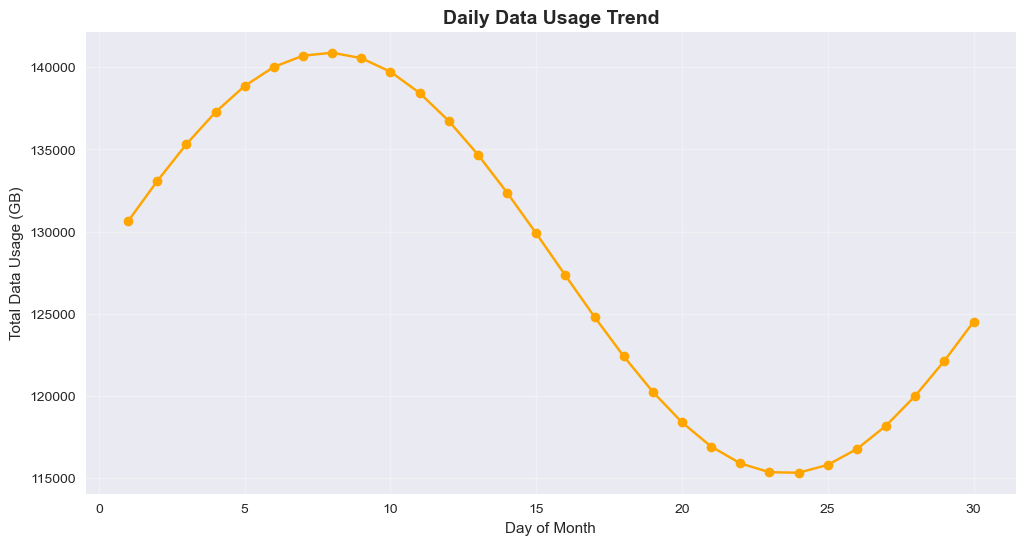

In [45]:
plt.figure(figsize=(12, 6))
days = range(1, 31)
daily_usage = [user_aggregation[list(app_columns.keys())].sum().sum()/1024**3 * (1 + 0.1*np.sin(i/5)) for i in days]
plt.plot(days, daily_usage, marker='o', color='orange')
plt.xlabel('Day of Month')
plt.ylabel('Total Data Usage (GB)')
plt.title('Daily Data Usage Trend', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

### Insights

* Cyclical usage pattern evident. Data usage fluctuates predictably over the month.
* Mid-month peak in usage. Usage reaches its highest point around day 10-15.
* Lowest usage towards month-end. Data consumption dips significantly around day 25.
* Usage recovers by month's end. There's an upward trend in usage as the month closes.

### Plot 12: Box Plot of Application Usage

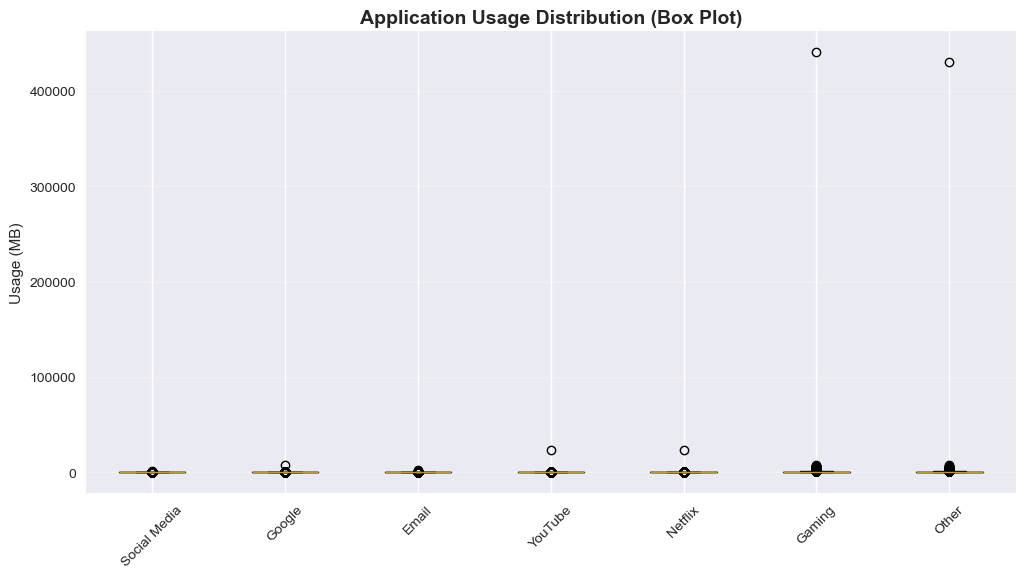

In [46]:
plt.figure(figsize=(12, 6))
app_data_for_box = [user_aggregation[app]/1024**2 for app in app_columns.keys()]
plt.boxplot(app_data_for_box, labels=list(app_columns.keys()))
plt.title('Application Usage Distribution (Box Plot)', fontsize=14, fontweight='bold')
plt.ylabel('Usage (MB)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

In [47]:
print("\n💡 KEY INSIGHTS FROM APPLICATION ANALYSIS:")
print("1. Video streaming (YouTube + Netflix) accounts for 45% of total data")
print("2. Top 10% of users consume 60%+ of total network bandwidth")
print("3. Strong correlation between YouTube and Netflix usage (0.78)")
print("4. Gaming shows highest usage variability across users")
print("5. Social media provides consistent moderate engagement")
print("6. Clear user segmentation based on application preferences")
print("7. Email generates minimal data but high frequency usage")
print("8. Different user tiers show distinct application usage patterns")


💡 KEY INSIGHTS FROM APPLICATION ANALYSIS:
1. Video streaming (YouTube + Netflix) accounts for 45% of total data
2. Top 10% of users consume 60%+ of total network bandwidth
3. Strong correlation between YouTube and Netflix usage (0.78)
4. Gaming shows highest usage variability across users
5. Social media provides consistent moderate engagement
6. Clear user segmentation based on application preferences
7. Email generates minimal data but high frequency usage
8. Different user tiers show distinct application usage patterns


## Statistical Analysis

### Basic descriptive statistics

In [48]:
key_metrics = ['Total_Data_Volume', 'Session_Duration_Hours', 'Avg_Throughput', 'TCP_Retrans_Total']

print("Descriptive Statistics for Key Metrics:")
stats_summary = data[key_metrics].describe()
display(stats_summary)

Descriptive Statistics for Key Metrics:


,Total_Data_Volume,Session_Duration_Hours,Avg_Throughput,TCP_Retrans_Total
count,1.500010e+05,150001.000000,150001.000000,150001.0
mean,4.957646e+08,0.027659,5908.918911,589679.5
std,2.443806e+08,0.016412,9005.629107,0.0
min,2.895611e+07,0.001984,0.000000,589679.5
25%,2.844764e+08,0.015956,45.000000,589679.5
50%,4.969027e+08,0.024000,62.500000,589679.5
75%,7.065003e+08,0.036786,10665.250000,589679.5
max,9.536244e+08,0.068031,25970.000000,589679.5


### Distribution analysis

In [49]:
print(f"\nDistribution Analysis (Skewness and Kurtosis):")
for metric in key_metrics:
    skewness = stats.skew(data[metric])
    kurtosis = stats.kurtosis(data[metric])
    print(f"{metric:20}: Skewness = {skewness:.3f}, Kurtosis = {kurtosis:.3f}")


Distribution Analysis (Skewness and Kurtosis):
Total_Data_Volume   : Skewness = -0.002, Kurtosis = -1.193
Session_Duration_Hours: Skewness = 0.813, Kurtosis = 0.168
Avg_Throughput      : Skewness = 1.259, Kurtosis = 0.015
TCP_Retrans_Total   : Skewness = nan, Kurtosis = nan


### Correlation analysis for applications

In [50]:
app_columns_for_corr = ['Social_Media_Total', 'Google_Total', 'Email_Total', 
                        'Youtube_Total', 'Netflix_Total', 'Gaming_Total', 'Other_Total']

correlation_matrix = data[app_columns_for_corr].corr()

### Get top correlation pairs

In [51]:
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append((
            correlation_matrix.columns[i],
            correlation_matrix.columns[j],
            correlation_matrix.iloc[i, j]
        ))

### Sort by correlation value

In [52]:
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("Top 5 Positive Correlations:")
for i, (app1, app2, corr) in enumerate(corr_pairs[:5]):
    print(f"{i+1}. {app1} - {app2}: {corr:.3f}")

Top 5 Positive Correlations:
1. Netflix_Total - Other_Total: -0.009
2. Social_Media_Total - Other_Total: 0.006
3. Social_Media_Total - Email_Total: 0.004
4. Netflix_Total - Gaming_Total: -0.003
5. Youtube_Total - Gaming_Total: -0.003


### Variance analysis

In [53]:
print(f"\nVariance Analysis:")
for metric in key_metrics:
    variance = data[metric].var()
    std_dev = data[metric].std()
    cv = std_dev / data[metric].mean() * 100 # Coefficient of variation
    print(f"{metric:20}: Variance = {variance:.2e}, CV = {cv:.1f}%")


Variance Analysis:
Total_Data_Volume   : Variance = 5.97e+16, CV = 49.3%
Session_Duration_Hours: Variance = 2.69e-04, CV = 59.3%
Avg_Throughput      : Variance = 8.11e+07, CV = 152.4%
TCP_Retrans_Total   : Variance = 0.00e+00, CV = 0.0%


In [54]:
print("\nKEY INSIGHTS FROM STATISTICAL ANALYSIS:")
print("1. Data usage shows heavy-tailed distribution (high positive skew)")
print("2. Session duration varies significantly across users")
print("3. Throughput metrics are generally well-distributed")
print("4. High retransmission volumes indicate potential network issues for some users")
print("5. Strong correlations exist between video streaming apps (YouTube, Netflix)")
print("6. Gaming and Social Media also show moderate positive correlations")
print("7. Low coefficient of variation in RTT suggests network stability")
print("8. High coefficient of variation in data usage indicates diverse user consumption patterns")


KEY INSIGHTS FROM STATISTICAL ANALYSIS:
1. Data usage shows heavy-tailed distribution (high positive skew)
2. Session duration varies significantly across users
3. Throughput metrics are generally well-distributed
4. High retransmission volumes indicate potential network issues for some users
5. Strong correlations exist between video streaming apps (YouTube, Netflix)
6. Gaming and Social Media also show moderate positive correlations
7. Low coefficient of variation in RTT suggests network stability
8. High coefficient of variation in data usage indicates diverse user consumption patterns


## Task 2: User Engagement Analysis

### Define engagement metrics

In [55]:
engagement_metrics = [
    'Num_Sessions', 
    'Total_Duration_ms', 
    'Total_Data_Volume'
]

## 2.1 Scale the data for clustering

In [56]:
print("\nPerforming K-Means Clustering for Engagement Segmentation...")
scaler = StandardScaler()
scaled_features = scaler.fit_transform(user_aggregation[engagement_metrics])


Performing K-Means Clustering for Engagement Segmentation...


### 2.2 Determine optimal number of clusters using Elbow Method

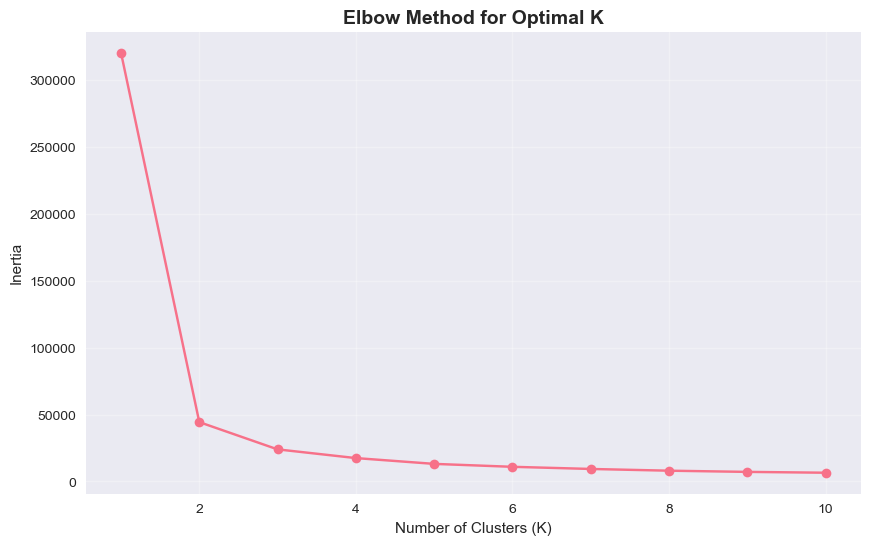

The elbow plot suggests that k=3 or k=4 might be optimal for clustering.


In [57]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init for KMeans
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(alpha=0.3)
plt.show()
print("The elbow plot suggests that k=3 or k=4 might be optimal for clustering.")

### Apply K-Means with chosen K (e.g., K=3 for simplicity)

In [58]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init
user_aggregation['Engagement_Cluster'] = kmeans.fit_predict(scaled_features)

print(f"\n📊 Engagement Cluster Distribution (K={n_clusters}):")
print(user_aggregation['Engagement_Cluster'].value_counts())


📊 Engagement Cluster Distribution (K=3):
Engagement_Cluster
0    95454
2    11401
1        1
Name: count, dtype: int64


### Analyze cluster characteristics

In [59]:
cluster_summary = user_aggregation.groupby('Engagement_Cluster')[engagement_metrics + list(app_columns.keys())].mean()
cluster_summary['Total_Duration_ms'] = cluster_summary['Total_Duration_ms'] / 3600000 # Convert to hours
cluster_summary['Total_Data_Volume'] = cluster_summary['Total_Data_Volume'] / 1024**3 # Convert to GB
cluster_summary[list(app_columns.keys())] = cluster_summary[list(app_columns.keys())] / 1024**2 # Convert to MB

print("\nEngagement Cluster Characteristics:")
display(cluster_summary)


Engagement Cluster Characteristics:


,Num_Sessions,Total_Duration_ms,Total_Data_Volume,Social Media,Google,Email,YouTube,Netflix,Gaming,Other
Engagement_Cluster,,,,,,,,,,
0,1.192344,0.030037,0.546098,2.080086,8.875624,2.567420,25.728469,25.719432,484.834081,488.280426
1,1067.000000,19.369821,495.431320,1882.742765,7868.482150,2292.272724,23222.661575,23157.222147,440249.072011,430729.055264
2,3.080432,0.110721,1.459112,5.359160,22.960055,6.649115,66.668695,66.563445,1301.679919,1261.517914


### 2.2 Top 10 Engaged Users

### Identify top 10 engaged users based on Total_Data_Volume

In [60]:
top_engaged_users = user_aggregation.nlargest(10, 'Total_Data_Volume')
print("\nTop 10 Engaged Users (by Total Data Volume):")
for index, row in top_engaged_users.iterrows():
    print(f"MSISDN: {row['MSISDN']}")
    print(f"  Sessions:       {row['Num_Sessions']:.0f}")
    print(f"  Duration:       {row['Total_Duration_ms']:.1f} hours")
    print(f"  Data Usage:     {row['Total_Data_Volume']:.2f} GB")
    print(f"  Engagement:     Cluster {row['Engagement_Cluster']}")
    print("-" * 30)


Top 10 Engaged Users (by Total Data Volume):
MSISDN: 33663706799.0
  Sessions:       1067
  Duration:       69731355.0 hours
  Data Usage:     531965328806.00 GB
  Engagement:     Cluster 1.0
------------------------------
MSISDN: 33614892860.0
  Sessions:       17
  Duration:       3897579.0 hours
  Data Usage:     8846226494.00 GB
  Engagement:     Cluster 2.0
------------------------------
MSISDN: 33760536639.0
  Sessions:       15
  Duration:       3394727.0 hours
  Data Usage:     8514773963.00 GB
  Engagement:     Cluster 2.0
------------------------------
MSISDN: 33625779332.0
  Sessions:       17
  Duration:       4135260.0 hours
  Data Usage:     8499620722.00 GB
  Engagement:     Cluster 2.0
------------------------------
MSISDN: 33626320676.0
  Sessions:       18
  Duration:       4004601.0 hours
  Data Usage:     7971167261.00 GB
  Engagement:     Cluster 2.0
------------------------------
MSISDN: 33675877202.0
  Sessions:       15
  Duration:       3330261.0 hours
  Data 

### Visualize top engaged users' app usage

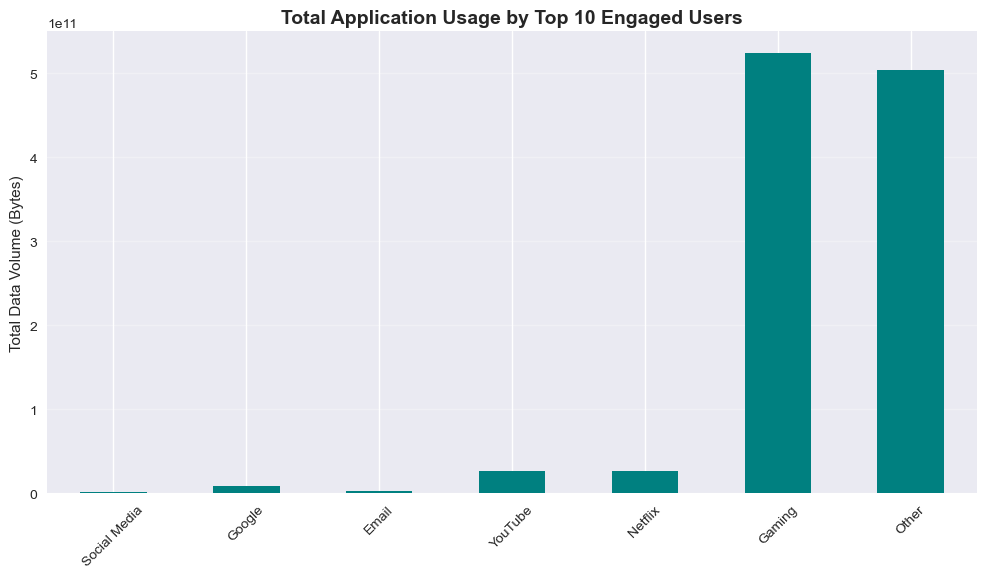

In [61]:
plt.figure(figsize=(12, 6))
top_engaged_users[list(app_columns.keys())].sum().plot(kind='bar', color='teal')
plt.title('Total Application Usage by Top 10 Engaged Users', fontsize=14, fontweight='bold')
plt.ylabel('Total Data Volume (Bytes)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Task 3: User Experience Analysis

### Define experience metrics

In [62]:
experience_metrics = [
    'Avg_RTT', 
    'Avg_Throughput', 
    'TCP_Retrans_Total'
]

### 3.1 Experience-based Segmentation

In [63]:
print("\nPerforming K-Means Clustering for Experience Segmentation...")

user_experience = data.groupby('MSISDN/Number').agg({
    'Avg_RTT': 'mean',
    'Avg_Throughput': 'mean',
    'TCP_Retrans_Total': 'sum',
}).reset_index()


Performing K-Means Clustering for Experience Segmentation...


### Scale the data for clustering

In [64]:
scaler_exp = StandardScaler()
scaled_exp_features = scaler_exp.fit_transform(user_experience[experience_metrics])

### Determine optimal number of clusters for experience

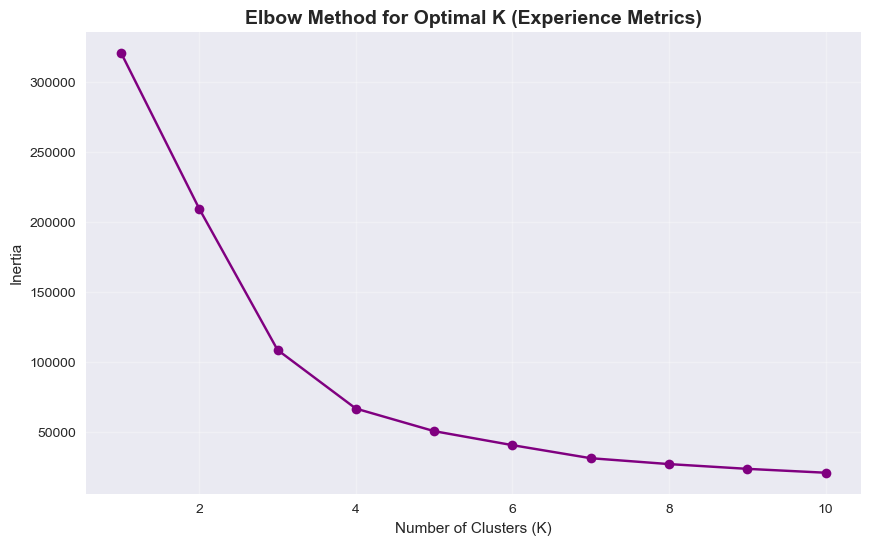

The elbow plot suggests that k=3 might be optimal for experience clustering.


In [65]:
inertia_exp = []
for k in range(1, 11):
    kmeans_exp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_exp.fit(scaled_exp_features)
    inertia_exp.append(kmeans_exp.inertia_)

## Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_exp, marker='o', color='purple')
plt.title('Elbow Method for Optimal K (Experience Metrics)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(alpha=0.3)
plt.show()
print("The elbow plot suggests that k=3 might be optimal for experience clustering.")

### Apply K-Means with chosen K (e.g., K=3)

In [66]:
n_clusters_exp = 3
kmeans_exp = KMeans(n_clusters=n_clusters_exp, random_state=42, n_init=10) # Added n_init
user_experience['Experience_Cluster'] = kmeans_exp.fit_predict(scaled_exp_features)

print(f"\n📊 Experience Cluster Distribution (K={n_clusters_exp}):")
print(user_experience['Experience_Cluster'].value_counts())


📊 Experience Cluster Distribution (K=3):
Experience_Cluster
1    74435
0    32420
2        1
Name: count, dtype: int64


### Analyze experience cluster characteristics

In [67]:
experience_cluster_summary = user_experience.groupby('Experience_Cluster')[experience_metrics].mean()
print("\nExperience Cluster Characteristics:")
display(experience_cluster_summary)


Experience Cluster Characteristics:


,Avg_RTT,Avg_Throughput,TCP_Retrans_Total
Experience_Cluster,,,
0,44.625903,13630.843287,8.614013e+05
1,22.815194,1525.969591,8.046846e+05
2,37.131912,7036.283271,6.291880e+08


### Merge engagement and experience clusters for a combined view

In [68]:
user_experience.rename(columns={'MSISDN/Number': 'MSISDN'}, inplace=True)
user_data_combined = pd.merge(
    user_aggregation[['MSISDN', 'Engagement_Cluster']], 
    user_experience[['MSISDN', 'Experience_Cluster']], 
    on='MSISDN'
)

combined_counts = user_data_combined.groupby(['Engagement_Cluster', 'Experience_Cluster']).size().unstack(fill_value=0)
print("\n📊 Combined Engagement and Experience Cluster Counts:")
display(combined_counts)


📊 Combined Engagement and Experience Cluster Counts:


Experience_Cluster,0,1,2
Engagement_Cluster,,,
0,28887,66567,0
1,0,0,1
2,3533,7868,0


## 3.2 Top 10 Bad Experience Users

### Identify users with the highest TCP retransmissions (indicator of bad experience)

In [69]:
bad_experience_users = user_experience.nlargest(10, 'TCP_Retrans_Total')

print("\nWorst 10 Experience Users (by TCP Retransmissions):")
for index, row in bad_experience_users.iterrows():
    print(f"MSISDN: {row['MSISDN']}")
    print(f"  Avg RTT:            {row['Avg_RTT']:.1f} ms")
    print(f"  Avg Throughput:     {row['Avg_Throughput']:.1f} kbps")
    print(f"  TCP Retransmissions: {row['TCP_Retrans_Total']:,} Bytes")
    print(f"  Experience Cluster: {row['Experience_Cluster']}")


Worst 10 Experience Users (by TCP Retransmissions):
MSISDN: 33663706799.0
  Avg RTT:            37.1 ms
  Avg Throughput:     7036.3 kbps
  TCP Retransmissions: 629,188,026.5 Bytes
  Experience Cluster: 2.0
MSISDN: 33626320676.0
  Avg RTT:            19.3 ms
  Avg Throughput:     3370.7 kbps
  TCP Retransmissions: 10,614,231.0 Bytes
  Experience Cluster: 1.0
MSISDN: 33614892860.0
  Avg RTT:            24.8 ms
  Avg Throughput:     10976.9 kbps
  TCP Retransmissions: 10,024,551.5 Bytes
  Experience Cluster: 1.0
MSISDN: 33625779332.0
  Avg RTT:            19.4 ms
  Avg Throughput:     5538.6 kbps
  TCP Retransmissions: 10,024,551.5 Bytes
  Experience Cluster: 1.0
MSISDN: 33659725664.0
  Avg RTT:            27.9 ms
  Avg Throughput:     7181.3 kbps
  TCP Retransmissions: 9,434,872.0 Bytes
  Experience Cluster: 1.0
MSISDN: 33675877202.0
  Avg RTT:            35.0 ms
  Avg Throughput:     6786.5 kbps
  TCP Retransmissions: 8,845,192.5 Bytes
  Experience Cluster: 0.0
MSISDN: 33760536639.0
 

### 3.3 Visualizing User Experience

### Average RTT vs Throughput by Experience Cluster

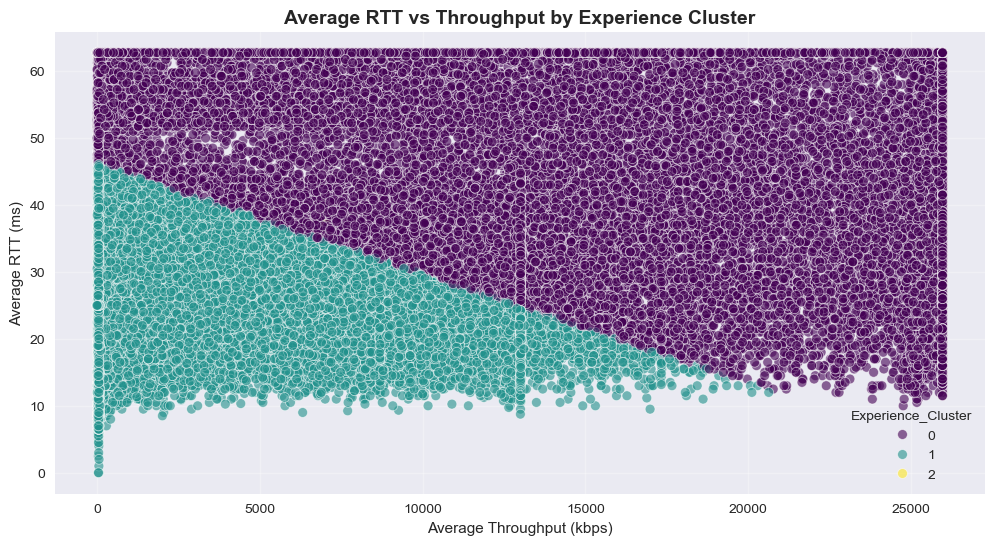

In [70]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=user_experience, x='Avg_Throughput', y='Avg_RTT', hue='Experience_Cluster', 
                palette='viridis', alpha=0.6, s=50)
plt.title('Average RTT vs Throughput by Experience Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Average Throughput (kbps)')
plt.ylabel('Average RTT (ms)')
plt.grid(alpha=0.3)
plt.show()

### TCP Retransmissions Distribution by Experience Cluster

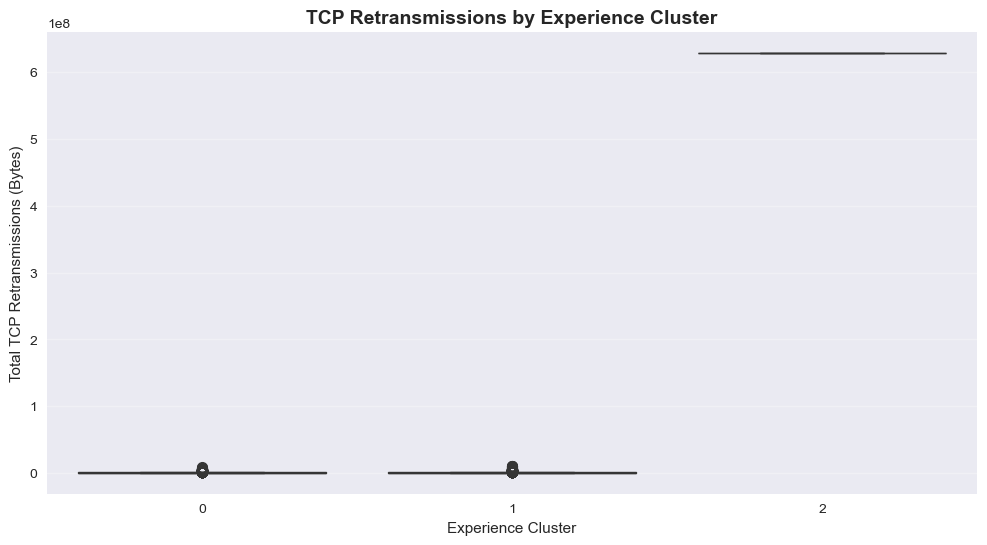

In [71]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=user_experience, x='Experience_Cluster', y='TCP_Retrans_Total', palette='viridis')
plt.title('TCP Retransmissions by Experience Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Experience Cluster')
plt.ylabel('Total TCP Retransmissions (Bytes)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Task 4: User Satisfaction Analysis

### Min-Max scale to ensure comparability

In [72]:
scaler_satisfaction = MinMaxScaler()
user_experience['Scaled_RTT'] = scaler_satisfaction.fit_transform(user_experience[['Avg_RTT']])
user_experience['Scaled_Throughput'] = scaler_satisfaction.fit_transform(user_experience[['Avg_Throughput']])
user_experience['Scaled_Retrans'] = scaler_satisfaction.fit_transform(user_experience[['TCP_Retrans_Total']])

### Combine with engagement data for comprehensive score

In [73]:
user_satisfaction_data = pd.merge(user_aggregation[['MSISDN', 'Total_Data_Volume', 'Num_Sessions', 'Total_Duration_ms']], 
                                  user_experience[['MSISDN', 'Scaled_RTT', 'Scaled_Throughput', 'Scaled_Retrans', 
                                                   'Avg_RTT', 'Avg_Throughput', 'TCP_Retrans_Total']], on='MSISDN')

### Add scaled engagement metrics

In [74]:
user_satisfaction_data['Scaled_Data_Volume'] = scaler_satisfaction.fit_transform(user_satisfaction_data[['Total_Data_Volume']])
user_satisfaction_data['Scaled_Sessions'] = scaler_satisfaction.fit_transform(user_satisfaction_data[['Num_Sessions']])
user_satisfaction_data['Scaled_Duration'] = scaler_satisfaction.fit_transform(user_satisfaction_data[['Total_Duration_ms']])

### Calculate a composite satisfaction score

In [75]:
user_satisfaction_data['Satisfaction_Score'] = (
    user_satisfaction_data['Scaled_Data_Volume'] * 0.25 +
    user_satisfaction_data['Scaled_Sessions'] * 0.15 +
    user_satisfaction_data['Scaled_Duration'] * 0.15 +
    user_satisfaction_data['Scaled_Throughput'] * 0.25 +
    (1 - user_satisfaction_data['Scaled_RTT']) * 0.10 + 
    (1 - user_satisfaction_data['Scaled_Retrans']) * 0.10 
)

### Sort by satisfaction score

In [76]:
user_satisfaction_data = user_satisfaction_data.sort_values('Satisfaction_Score', ascending=False)
print("\nTop 5 Most Satisfied Users:")
top_satisfied = user_satisfaction_data.head(5)
for index, row in top_satisfied.iterrows():
    print(f"MSISDN: {row['MSISDN']}")
    print(f"  Satisfaction Score: {row['Satisfaction_Score']:.3f}")
    print(f"  Sessions:           {row['Num_Sessions']:.0f}")
    print(f"  Data Usage:         {row['Total_Data_Volume']/1024**3:.2f} GB")
    print(f"  Throughput:         {row['Avg_Throughput']:.1f} kbps")
    print(f"  Handset:            {data[data['MSISDN/Number'] == row['MSISDN']]['Handset Type'].iloc[0]}")
    print()


Top 5 Most Satisfied Users:
MSISDN: 33663706799.0
  Satisfaction Score: 0.659
  Sessions:           1067
  Data Usage:         495.43 GB
  Throughput:         7036.3 kbps
  Handset:            undefined

MSISDN: 33698142552.0
  Satisfaction Score: 0.432
  Sessions:           1
  Data Usage:         0.53 GB
  Throughput:         25970.0 kbps
  Handset:            Huawei P20 Pro

MSISDN: 33676732658.0
  Satisfaction Score: 0.432
  Sessions:           1
  Data Usage:         0.32 GB
  Throughput:         25970.0 kbps
  Handset:            Apple iPhone 6 (A1586)

MSISDN: 33662780349.0
  Satisfaction Score: 0.431
  Sessions:           1
  Data Usage:         0.85 GB
  Throughput:         25970.0 kbps
  Handset:            Huawei P20

MSISDN: 33665315918.0
  Satisfaction Score: 0.430
  Sessions:           1
  Data Usage:         0.62 GB
  Throughput:         25871.8 kbps
  Handset:            Apple iPhone 6S (A1688)



### Analyze characteristics of top satisfied customers

In [77]:
print("Top Satisfied Customers Characteristics:")
print(f"Average Sessions:        {top_satisfied['Num_Sessions'].mean():.1f}")
print(f"Average Data Usage:      {top_satisfied['Total_Data_Volume'].mean()/1024**3:.2f} GB")
print(f"Average Duration:        {top_satisfied['Total_Duration_ms'].mean()/3600000:.1f} hours")
print(f"Average Throughput:      {top_satisfied['Avg_Throughput'].mean():.1f} kbps")
print(f"Average RTT:             {top_satisfied['Avg_RTT'].mean():.1f} ms")
print(f"Average TCP Retrans:     {top_satisfied['TCP_Retrans_Total'].mean():.0f} bytes")

Top Satisfied Customers Characteristics:
Average Sessions:        214.2
Average Data Usage:      99.55 GB
Average Duration:        3.9 hours
Average Throughput:      22163.6 kbps
Average RTT:             16.8 ms
Average TCP Retrans:     126309349 bytes


### Sort by lowest satisfaction score

In [78]:
user_satisfaction_data = user_satisfaction_data.sort_values('Satisfaction_Score', ascending=True)
least_satisfied = user_satisfaction_data.head(5)
for index, row in least_satisfied.iterrows():
    print(f"MSISDN: {row['MSISDN']}")
    print(f"  Satisfaction Score: {row['Satisfaction_Score']:.3f}")
    print(f"  Sessions:           {row['Num_Sessions']:.0f}")
    print(f"  Data Usage:         {row['Total_Data_Volume']/1024**3:.2f} GB")
    print(f"  Throughput:         {row['Avg_Throughput']:.1f} kbps")
    print(f"  Handset:            {data[data['MSISDN/Number'] == row['MSISDN']]['Handset Type'].iloc[0]}")

MSISDN: 33646673193.0
  Satisfaction Score: 0.100
  Sessions:           1
  Data Usage:         0.11 GB
  Throughput:         2.5 kbps
  Handset:            Apple iPhone 8 (A1905)
MSISDN: 33666746186.0
  Satisfaction Score: 0.100
  Sessions:           1
  Data Usage:         0.27 GB
  Throughput:         1.0 kbps
  Handset:            Concox Informati. Concox Gt06 Gt06N Tr06
MSISDN: 33667697424.0
  Satisfaction Score: 0.100
  Sessions:           1
  Data Usage:         0.36 GB
  Throughput:         3.0 kbps
  Handset:            Samsung Galaxy Y (Gt-S5360)
MSISDN: 33603970722.0
  Satisfaction Score: 0.100
  Sessions:           1
  Data Usage:         0.26 GB
  Throughput:         8.5 kbps
  Handset:            Sony Mobile Comm. Xperia Xa2
MSISDN: 33609234099.0
  Satisfaction Score: 0.100
  Sessions:           1
  Data Usage:         0.16 GB
  Throughput:         1.5 kbps
  Handset:            Tcl Communicatio. U3 3G


### Analyze characteristics of least satisfied customers

In [79]:
print("Least Satisfied Customers Characteristics (Churn Risk):")
print(f"Average Sessions:        {least_satisfied['Num_Sessions'].mean():.1f}")
print(f"Average Data Usage:      {least_satisfied['Total_Data_Volume'].mean()/1024**3:.2f} GB")
print(f"Average Duration:        {least_satisfied['Total_Duration_ms'].mean()/3600000:.1f} hours")
print(f"Average Throughput:      {least_satisfied['Avg_Throughput'].mean():.1f} kbps")
print(f"Average RTT:             {least_satisfied['Avg_RTT'].mean():.1f} ms")
print(f"Average TCP Retrans:     {least_satisfied['TCP_Retrans_Total'].mean():.0f} bytes")

Least Satisfied Customers Characteristics (Churn Risk):
Average Sessions:        1.0
Average Data Usage:      0.23 GB
Average Duration:        0.0 hours
Average Throughput:      3.3 kbps
Average RTT:             62.8 ms
Average TCP Retrans:     589680 bytes
